(32700, 6)


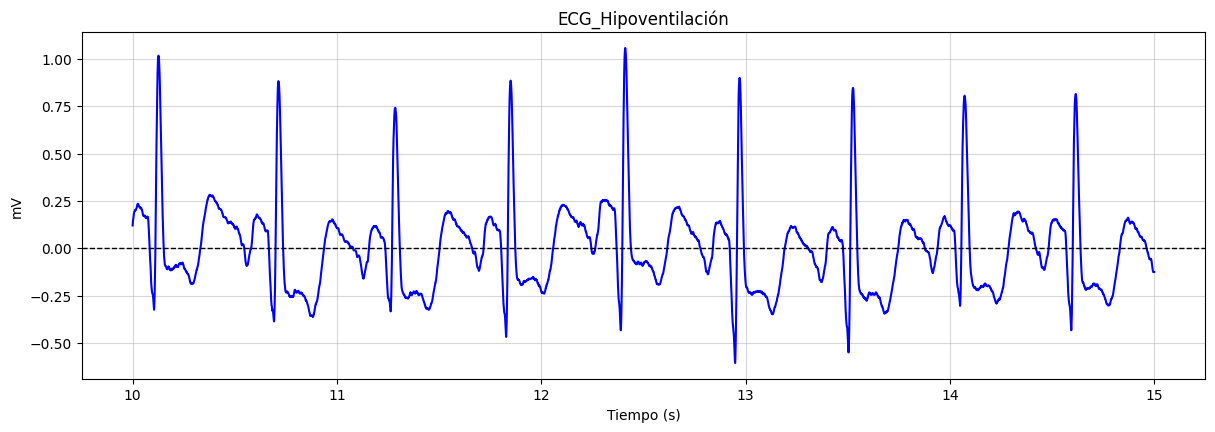

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta del archivo
file_path = "/content/drive/MyDrive/vallejo/Lab5-signals/HIPOVENTILACION1_II.txt"

# Leer saltando comentarios (#)
data = pd.read_csv(file_path, comment='#', sep='\t', header=None, usecols=range(6))
# Asignar nombres de columnas
data.columns = ["nSeq", "I1", "I2", "O1", "O2", "A2"]
data.head()
print(data.shape)
ecg_adc = data["A2"].values

#Variables
n = 10
Vcc = 3.3
G = 1100
fs = 1000
t = np.arange(len(ecg_adc)) / fs
t_inicio = 10
t_fin = 15

# Conversión a mV
ecg_mv = ((ecg_adc / (2**n)) - 0.5) * (Vcc / G) * 1000
ecg_mv = ecg_mv - np.mean(ecg_mv)


ecg_mv = -ecg_mv # Opcinal porque las señales salieron hacia abajo

# Ventana
duracion = t_fin - t_inicio
mask = (t >= t_inicio) & (t <= t_fin)

plt.figure(figsize=(14.5,4.5))
plt.plot(t[mask], ecg_mv[mask], color='blue')
# línea en y = 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.5)
plt.xlabel("Tiempo (s)")
plt.ylabel("mV")
plt.title(f"ECG_Hipoventilación")
plt.show()